## Модель для предварительного одобрения кредитного продукта

[ссылка на соревнование от Тинькофф](https://www.kaggle.com/competitions/fintech-credit-scoring/overview)

Задача: Для построения модели кредитного скоринга (предварительное одобрение кредитной карты при заполнении онлайн-анекты на сайте банка), нужно отобрать 5-10 признаков. Признаки должны быть простыми в понимании (пользователь должен без труда заполнить анкету, поэтому вопросы должны касаться непосредственно клиента и не содержать специализированную информацию, которую о нем собирают финансовые организации)

In [1]:
import pandas as pd
import phik
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from plot_countplots import plot_countplots
import warnings

from catboost import CatBoostClassifier, cv, Pool
from sklearn.feature_selection import GenericUnivariateSelect, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                             PrecisionRecallDisplay, classification_report,
                             precision_score, recall_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import optuna


In [2]:
RANDOM_STATE = 4242
TEST_SIZE = 0.3

In [3]:
warnings.filterwarnings('ignore')

### Загрузка данных

In [4]:
application_info = pd.read_csv("data/application_info.csv")
application_info.head()

,id,application_dt,sample_cd,education_cd,gender_cd,age,car_own_flg,car_type_flg,appl_rej_cnt,good_work_flg,Score_bki,out_request_cnt,region_rating,home_address_cd,work_address_cd,income,SNA,first_time_cd,Air_flg
0,1,01JAN2014,train,SCH,M,27,Y,Y,0,0,-1.917831,0,40,2,3,32000,1,4,N
1,2,01JAN2014,train,GRD,F,26,N,N,0,0,-1.153144,2,60,2,3,50000,2,1,N
2,3,01JAN2014,train,SCH,M,35,N,N,0,1,-1.732810,0,40,1,2,20000,4,3,N
3,4,01JAN2014,train,GRD,F,35,N,N,0,1,-2.552133,2,20,2,3,80000,1,3,N
4,5,01JAN2014,train,UGR,F,24,N,N,0,0,-1.914581,1,50,2,3,27000,1,2,N


In [5]:
application_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205296 entries, 0 to 205295
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               205296 non-null  int64  
 1   application_dt   205296 non-null  object 
 2   sample_cd        205296 non-null  object 
 3   education_cd     204384 non-null  object 
 4   gender_cd        205296 non-null  object 
 5   age              205296 non-null  int64  
 6   car_own_flg      205296 non-null  object 
 7   car_type_flg     205296 non-null  object 
 8   appl_rej_cnt     205296 non-null  int64  
 9   good_work_flg    205296 non-null  int64  
 10  Score_bki        205296 non-null  float64
 11  out_request_cnt  205296 non-null  int64  
 12  region_rating    205296 non-null  int64  
 13  home_address_cd  205296 non-null  int64  
 14  work_address_cd  205296 non-null  int64  
 15  income           205296 non-null  int64  
 16  SNA              205296 non-null  int6

Сразу удалим признаки, которые на мой взгляд являются наименее значимыми в вопросе одобрения кредита, а также будут непонятными для клиента, при заполнении онлайн заявки для предварительного одобрения кредитного продукта

In [6]:
data = application_info.drop(["application_dt", "appl_rej_cnt", "Score_bki", "out_request_cnt", 
                              "region_rating", "home_address_cd", "work_address_cd", "SNA",
                              "first_time_cd", "sample_cd"], axis=1)

In [7]:
data.sample(5)

,id,education_cd,gender_cd,age,car_own_flg,car_type_flg,good_work_flg,income,Air_flg
172508,172509,UGR,M,26,Y,Y,0,60000,N
18076,18077,GRD,F,53,N,N,1,35000,N
159529,159530,SCH,F,37,Y,Y,0,20000,N
158755,158756,SCH,M,36,Y,N,0,23000,N
172796,172797,SCH,F,29,N,N,0,15000,N


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205296 entries, 0 to 205295
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             205296 non-null  int64 
 1   education_cd   204384 non-null  object
 2   gender_cd      205296 non-null  object
 3   age            205296 non-null  int64 
 4   car_own_flg    205296 non-null  object
 5   car_type_flg   205296 non-null  object
 6   good_work_flg  205296 non-null  int64 
 7   income         205296 non-null  int64 
 8   Air_flg        205296 non-null  object
dtypes: int64(4), object(5)
memory usage: 14.1+ MB


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
for i in data[["gender_cd", "car_own_flg", "car_type_flg", "Air_flg"]]:
    print(f'Колонка {i} содержит уникальные значения: {data[i].unique()}')

Колонка gender_cd содержит уникальные значения: ['M' 'F']
Колонка car_own_flg содержит уникальные значения: ['Y' 'N']
Колонка car_type_flg содержит уникальные значения: ['Y' 'N']
Колонка Air_flg содержит уникальные значения: ['N' 'Y']


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,205296.0,102648.500000,59263.994769,1.0,51324.75,102648.5,153972.25,205296.0
age,205296.0,39.354566,11.451011,21.0,30.00,37.0,48.00,72.0
good_work_flg,205296.0,0.169701,0.375371,0.0,0.00,0.0,0.00,1.0
income,205296.0,42251.807610,45183.110679,1000.0,20000.00,30000.0,50000.00,1000000.0


In [12]:
data.query('income > 75000').shape[0]

20694

In [13]:
data.education_cd.value_counts(dropna=False)

education_cd
SCH    100234
GRD     71417
UGR     28284
PGR      3841
NaN       912
ACD       608
Name: count, dtype: int64

In [14]:
data['education_cd'] = data['education_cd'].fillna("without_education")

In [15]:
data.isna().sum()

id               0
education_cd     0
gender_cd        0
age              0
car_own_flg      0
car_type_flg     0
good_work_flg    0
income           0
Air_flg          0
dtype: int64

In [16]:
# Приведем бинарные признаки к виду {No:0, Yes:1}
# for i in data[["car_own_flg", "car_type_flg", "Air_flg"]]:
#     data[i] = data[i].map({'N': 0, 'Y': 1})
data['good_work_flg'] = data['good_work_flg'].map({0: 'N', 1: 'Y'})

In [17]:
data.head()

,id,education_cd,gender_cd,age,car_own_flg,car_type_flg,good_work_flg,income,Air_flg
0,1,SCH,M,27,Y,Y,N,32000,N
1,2,GRD,F,26,N,N,N,50000,N
2,3,SCH,M,35,N,N,Y,20000,N
3,4,GRD,F,35,N,N,Y,80000,N
4,5,UGR,F,24,N,N,N,27000,N


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205296 entries, 0 to 205295
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             205296 non-null  int64 
 1   education_cd   205296 non-null  object
 2   gender_cd      205296 non-null  object
 3   age            205296 non-null  int64 
 4   car_own_flg    205296 non-null  object
 5   car_type_flg   205296 non-null  object
 6   good_work_flg  205296 non-null  object
 7   income         205296 non-null  int64 
 8   Air_flg        205296 non-null  object
dtypes: int64(3), object(6)
memory usage: 14.1+ MB


In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
target = pd.read_csv("data/default_flg.csv")

In [21]:
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           180816 non-null  int64
 1   default_flg  180816 non-null  int64
dtypes: int64(2)
memory usage: 2.8 MB


In [22]:
df = data.merge(target, how='right', on='id')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180816 entries, 0 to 180815
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             180816 non-null  int64 
 1   education_cd   180816 non-null  object
 2   gender_cd      180816 non-null  object
 3   age            180816 non-null  int64 
 4   car_own_flg    180816 non-null  object
 5   car_type_flg   180816 non-null  object
 6   good_work_flg  180816 non-null  object
 7   income         180816 non-null  int64 
 8   Air_flg        180816 non-null  object
 9   default_flg    180816 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 13.8+ MB


### EDA

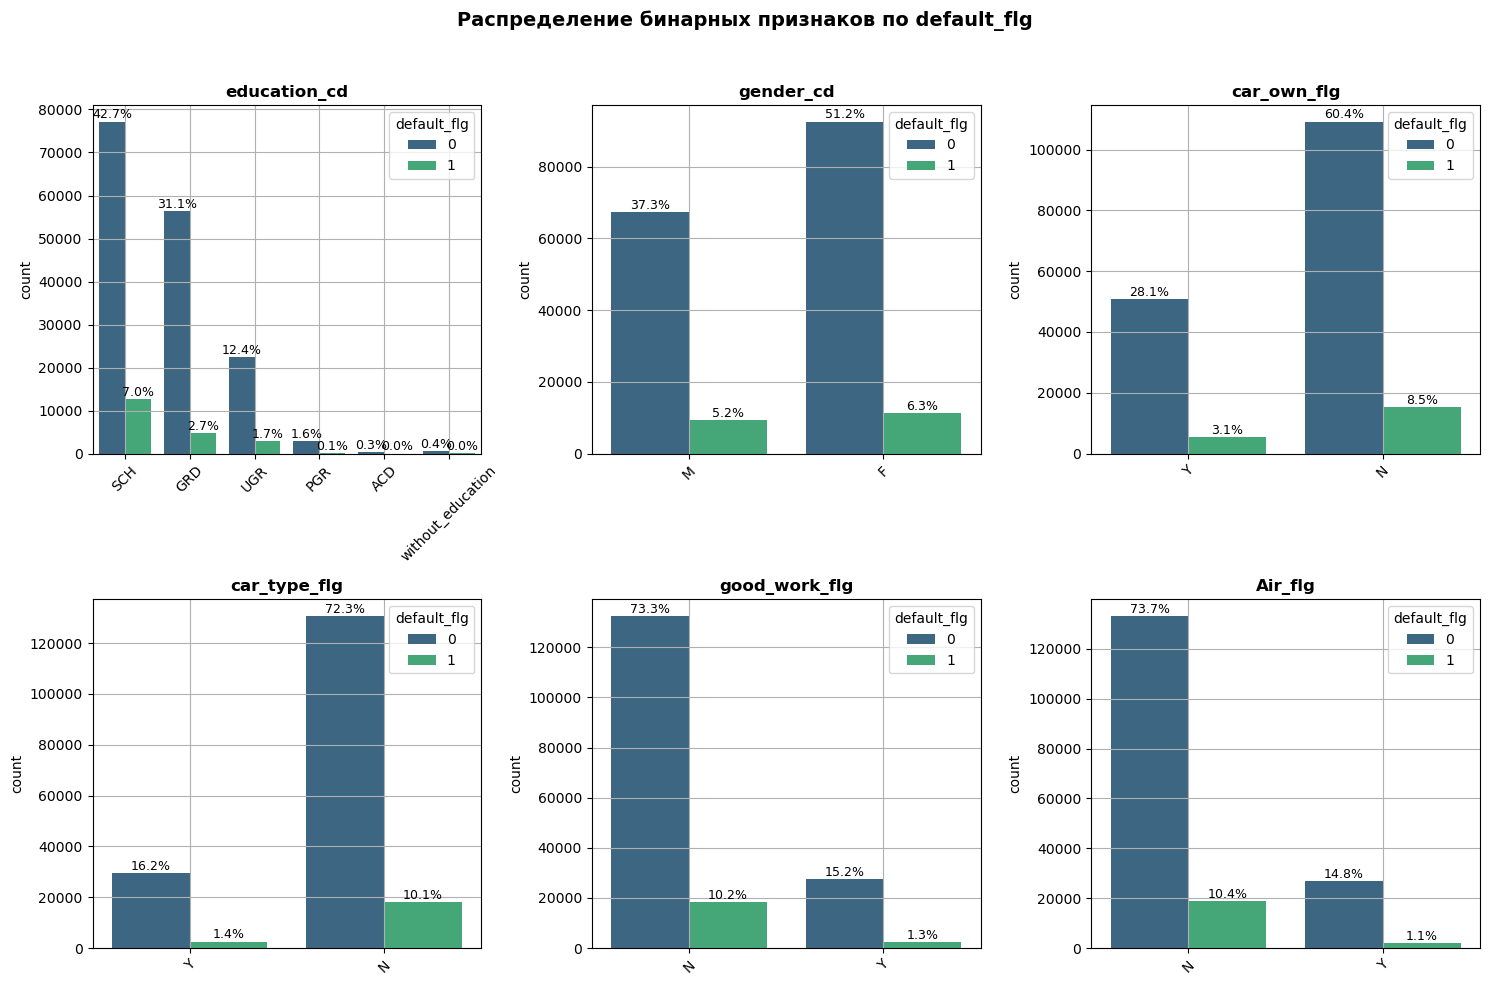

In [24]:
plot_countplots(df, 
                ['education_cd', 
                 'gender_cd', 
                 'car_own_flg', 
                 'car_type_flg', 
                 'good_work_flg', 
                 'Air_flg'], 
                 'default_flg')

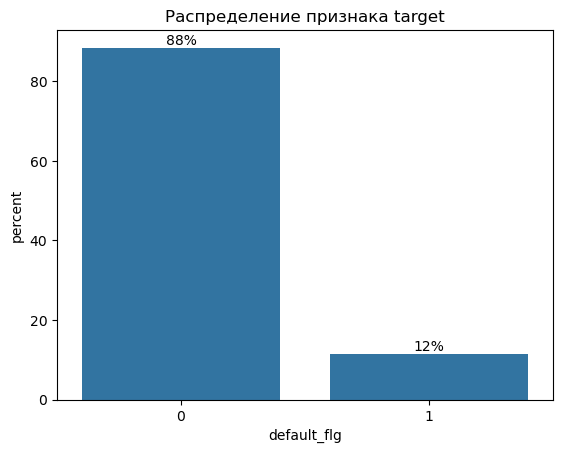

In [25]:
ax = sns.countplot(data=df, x='default_flg', stat='percent')

for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%')
plt.title(f'Распределение признака target')
plt.show()

Классы целевого признака не сбалансированы

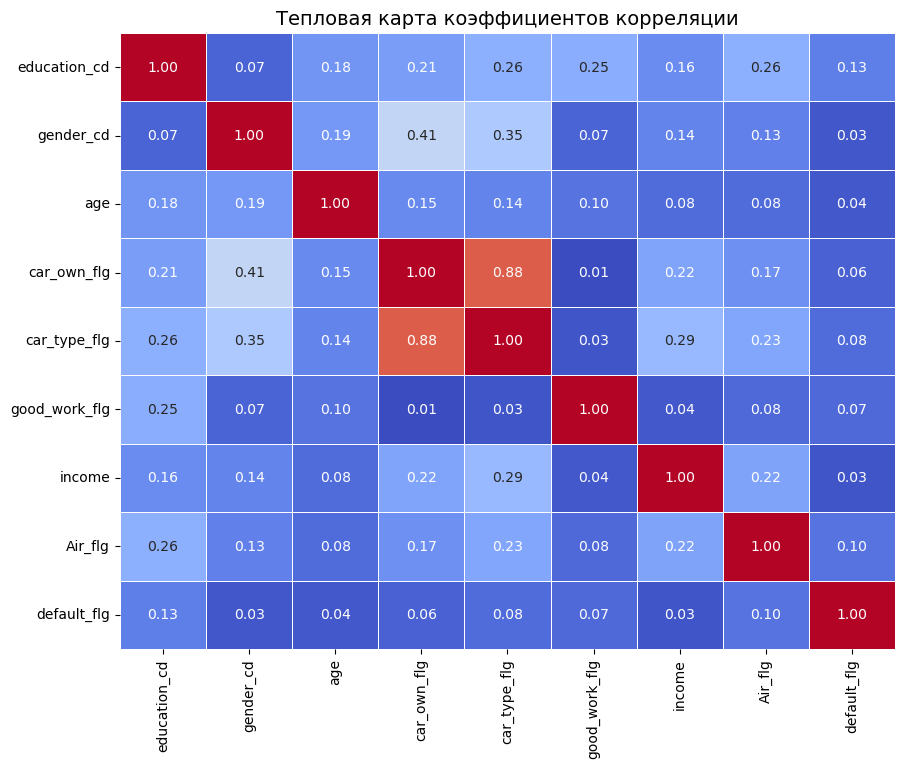

In [26]:
# Вычисление матрицы корреляции с использованием phik 
# Построим тепловую карту коэффициентов корреляции рассчитаных с использованием phik 
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('id', axis=1).phik_matrix(interval_cols = ['income', 'age',]), 
            annot=True, fmt=".2f", cmap='coolwarm', cbar=False, linewidths=0.5)
plt.title('Тепловая карта коэффициентов корреляции', fontsize=14)
plt.show()

### Подготовка данных к обучению

In [27]:
df.to_csv('data/final_data.csv', index=False, encoding='utf-8')

In [28]:
# Разбиваем данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(df.drop(['id', 'default_flg'], axis=1),
                                                    df['default_flg'],
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE, 
                                                    stratify = df['default_flg']
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((126571, 8), (54245, 8), (126571,), (54245,))

In [29]:
# Выделим количественные признаки
num_columns = ['age', 'income']
# Выделим категориальные признаки
ohe_columns = df.select_dtypes(exclude='number').columns.tolist()
ohe_columns

['education_cd',
 'gender_cd',
 'car_own_flg',
 'car_type_flg',
 'good_work_flg',
 'Air_flg']

In [30]:
# Пайплайн для подготовки категориальных признаков
ohe_pipe = Pipeline(
    [('simpleImputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [31]:
# Общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', StandardScaler(), num_columns) 
    ],
    remainder='passthrough'
)

In [32]:
X_train_pre = data_preprocessor.fit_transform(X_train)
X_test_pre = data_preprocessor.transform(X_test)

### LogisticRegression

In [33]:
pipe_lr= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
    ]
)

pipe_lr.fit(X_train, y_train) 
print(f'Метрика roc_auc на трейне: {roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])}')
print(f'Метрика precision на трейне: {precision_score(y_train, pipe_lr.predict(X_train))}')
print(f'Метрика recall на трейне: {recall_score(y_train, pipe_lr.predict(X_train))}')

Метрика roc_auc на трейне: 0.613346590751872
Метрика precision на трейне: 0.14710832313341493
Метрика recall на трейне: 0.6592841470104224


In [34]:
print(f'Метрика roc_auc на тесте: {roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:, 1])}')
print(f'Метрика precision на тесте: {precision_score(y_test, pipe_lr.predict(X_test))}')
print(f'Метрика recall на тесте: {recall_score(y_test, pipe_lr.predict(X_test))}')

Метрика roc_auc на тесте: 0.6063814797374726
Метрика precision на тесте: 0.14459681451324904
Метрика recall на тесте: 0.64784


In [35]:
results = pd.DataFrame(columns=['model', 'roc_auc'])
results.loc[len(results)] = ['LinearRegression', 
                             roc_auc_score(y_train, pipe_lr.predict_proba(X_train)[:, 1])]
results

,model,roc_auc
0,LinearRegression,0.613347


### RandomForestClassifier

In [36]:
clf_rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)

params = {
    "max_features": optuna.distributions.CategoricalDistribution(["sqrt", "log2", None]),
    "n_estimators" : optuna.distributions.IntDistribution(20, 300, step=20),
    "max_depth" : optuna.distributions.IntDistribution(1, 20, step=1),
    "min_samples_split" : optuna.distributions.IntDistribution(2, 20),
    "min_samples_leaf" : optuna.distributions.IntDistribution(1, 20)
} 

optuna_search = optuna.integration.OptunaSearchCV(clf_rf,
                                                  params,
                                                  scoring='roc_auc',
                                                  cv=StratifiedKFold(),
                                                  n_trials=100,
                                                  n_jobs=-1,
                                                  verbose=0,
                                                  random_state=RANDOM_STATE)

In [37]:
%%time
optuna_search.fit(X_train_pre, y_train)

[I 2026-02-23 23:04:59,211] A new study created in memory with name: no-name-d7c31f71-736e-4102-95ee-fd12460fb242
[I 2026-02-23 23:05:19,558] Trial 1 finished with value: 0.6009015695268964 and parameters: {'max_features': 'sqrt', 'n_estimators': 80, 'max_depth': 1, 'min_samples_split': 11, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.6009015695268964.
[I 2026-02-23 23:05:30,646] Trial 16 finished with value: 0.6008437745545028 and parameters: {'max_features': 'log2', 'n_estimators': 40, 'max_depth': 1, 'min_samples_split': 11, 'min_samples_leaf': 17}. Best is trial 1 with value: 0.6009015695268964.
[I 2026-02-23 23:05:49,582] Trial 11 finished with value: 0.5987353286386895 and parameters: {'max_features': None, 'n_estimators': 80, 'max_depth': 2, 'min_samples_split': 15, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.6009015695268964.
[I 2026-02-23 23:06:06,037] Trial 7 finished with value: 0.6154373053164053 and parameters: {'max_features': None, 'n_estimators': 60, 

CPU times: total: 3h 24min 12s
Wall time: 16min 26s


OptunaSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
               estimator=RandomForestClassifier(class_weight='balanced',
                                                random_state=4242),
               n_jobs=-1, n_trials=100,
               param_distributions={'max_depth': IntDistribution(high=20, log=False, low=1, step=1),
                                    'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)),
                                    'min_samples_leaf': IntDistribution(high=20, log=False, low=1, step=1),
                                    'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1),
                                    'n_estimators': IntDistribution(high=300, log=False, low=20, step=20)},
               random_state=4242, scoring='roc_auc')

In [38]:
optuna_search.best_score_

0.6165937513851537

In [39]:
optuna_search.best_params_

{'max_features': 'sqrt',
 'n_estimators': 300,
 'max_depth': 8,
 'min_samples_split': 17,
 'min_samples_leaf': 15}

In [40]:
results.loc[len(results)] = ['RandomForestClassifier', 
                             optuna_search.best_score_]
results

,model,roc_auc
0,LinearRegression,0.613347
1,RandomForestClassifier,0.616594


### CatBoostClassifier

In [41]:
pool = Pool(X_train, y_train, cat_features=ohe_columns)

In [42]:
# Зададим фиксированные параметры для модели
FIXED_PARAMS = {
    "early_stopping_rounds": 20, 
    "scale_pos_weight": 5.0, 
    "objective": 'Logloss', 
    "eval_metric": 'AUC', 
    "logging_level": "Silent", 
    "random_seed": RANDOM_STATE
}

In [43]:
def objective(trial):   
    opt_params = {
        "iterations" : trial.suggest_int("iterations", 100, 1500),
        "depth": trial.suggest_int("depth", 1, 16, step=1),
        "learning_rate" : trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    }
    
    param = {**FIXED_PARAMS, **opt_params}
   
    cv_data = cv(
            pool=pool,
            params=param,
            fold_count=5,  
            shuffle=True,
            partition_random_seed=RANDOM_STATE,
            plot=False,
            verbose=False,
            stratified=True 
)
    return cv_data['test-AUC-mean'].max()

In [44]:
study = optuna.create_study(direction="maximize")

[I 2026-02-23 23:21:26,416] A new study created in memory with name: no-name-c3338dd6-b0fc-4626-82eb-e23169623c5a


In [45]:
%%time
study.optimize(objective, n_trials=100, n_jobs=-1, show_progress_bar=True)

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-23 23:26:37,687] Trial 2 finished with value: 0.6019241119231487 and parameters: {'iterations': 118, 'depth': 8, 'learning_rate': 0.008131161279202662}. Best is trial 2 with value: 0.6019241119231487.
[I 2026-02-23 23:28:15,671] Trial 6 finished with value: 0.6036335183233802 and parameters: {'iterations': 535, 'depth': 3, 'learning_rate': 0.0049991800654930925}. Best is trial 6 with value: 0.6036335183233802.
[I 2026-02-23 23:29:37,068] Trial 11 finished with value: 0.6177213582803585 and parameters: {'iterations': 581, 'depth': 8, 'learning_rate': 0.06408552819425378}. Best is trial 11 with value: 0.6177213582803585.
[I 2026-02-23 23:31:13,761] Trial 4 finished with value: 0.615096900468213 and parameters: {'iterations': 825, 'depth': 1, 'learning_rate': 0.2385867243449901}. Best is trial 11 with value: 0.6177213582803585.
[I 2026-02-23 23:31:46,838] Trial 12 finished with value: 0.6177992854205417 and parameters: {'iterations': 229, 'depth': 4, 'learning_rate': 0.09925775

In [46]:
study.best_params

{'iterations': 1414, 'depth': 5, 'learning_rate': 0.09203766170623374}

In [47]:
study.best_value

0.6185680361755163

In [48]:
results.loc[len(results)] = ['CatBoostClassifier', 
                             study.best_value]
results

,model,roc_auc
0,LinearRegression,0.613347
1,RandomForestClassifier,0.616594
2,CatBoostClassifier,0.618568
